# Question 2 : Improved Models, Enhancement, and Deployment

**Objective:** improve on the baseline logistic-regression model from Question 1 by training multiple machine-learning models, applying an additional performance enhancement, and deploying the best configuration in a web interface.


**Contents:**
- **2.1** Train 4+ models and compare against the baseline
- **2.2** Apply one additional performance enhancement
- **2.3** Save the best model for deployment in the Streamlit app


## 2.1) Training Multiple Models

**Goal:** train four different classifiers on the same TF-IDF feature matrix and compare their test performance against the Q1 baseline.

**Models:**
1. **Linear SVM** - strong baseline for sparse text data, often outperforms logistic regression.
2. **Multinomial Naive Bayes** - the classic text classifier; extremely fast, strong on imbalanced text.
3. **Random Forest** - nonlinear ensemble; captures feature interactions but struggles with very high-dimensional sparse data.
4. **XGBoost (Gradient Boosting)** - state-of-the-art for tabular/sparse features; handles imbalance well via scale_pos_weight.

**Evaluation protocol:** stratified 80/20 split with `random_state=42` which is  identical to Q1 so the comparison is fair.

In [2]:
import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Reload cleaned dataset
df = pd.read_json('../data/research_abstracts_clean.json')

# Same TF-IDF settings as Q1 (fair comparison)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                        min_df=3, max_df=0.9, sublinear_tf=True)
X = tfidf.fit_transform(df['clean'])
y = df['label'].values

# Same stratified split as Q1
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train labels:", pd.Series(y_train).value_counts().to_dict())

Train: (910, 5000)  Test: (228, 5000)
Train labels: {'classical': 720, 'ai': 190}


In [3]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, precision_score, recall_score)
from sklearn.preprocessing import LabelEncoder

# Encode labels 0/1 for XGBoost compatibility
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)   # 'ai'→0, 'classical'→1
y_test_enc  = le.transform(y_test)

# Imbalance ratio for XGBoost
neg, pos = (y_train_enc == 1).sum(), (y_train_enc == 0).sum()

models = {
    "Linear SVM":    CalibratedClassifierCV(
                        LinearSVC(max_iter=2000, class_weight='balanced', random_state=42)),
    "Naive Bayes":   MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                            n_jobs=-1, random_state=42),
    "XGBoost":       XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                                   eval_metric='logloss', random_state=42,
                                   scale_pos_weight=neg/pos),
}

results = []

for name, model in models.items():
    t0 = time.time()

    # XGBoost gets encoded labels; others get original strings
    if name == "XGBoost":
        model.fit(X_train, y_train_enc)
        y_pred_enc = model.predict(X_test)
        y_pred = le.inverse_transform(y_pred_enc)
        y_prob = model.predict_proba(X_test)[:, 0]  # probability of class 0 = 'ai'
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]  # 'ai' is index 1 in sklearn's sorted labels

    train_time = round(time.time() - t0, 2)

    results.append({
        "Model":         name,
        "Accuracy":      round(accuracy_score(y_test, y_pred), 4),
        "Precision(AI)": round(precision_score(y_test, y_pred, pos_label='ai'), 4),
        "Recall(AI)":    round(recall_score(y_test, y_pred, pos_label='ai'), 4),
        "F1(AI)":        round(f1_score(y_test, y_pred, pos_label='ai'), 4),
        "Macro F1":      round(f1_score(y_test, y_pred, average='macro'), 4),
        "ROC-AUC":       round(roc_auc_score(y_test, y_prob), 4),
        "Time(s)":       train_time,
    })
    print(f"{name:18s} | acc={results[-1]['Accuracy']:.4f} | F1(ai)={results[-1]['F1(AI)']:.4f} | macroF1={results[-1]['Macro F1']:.4f} | AUC={results[-1]['ROC-AUC']:.4f} | {train_time}s")

results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False).reset_index(drop=True)
print("\nRanking (by Macro F1):")
results_df

c:\Users\dinne\anaconda3\envs\research_clf\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\dinne\anaconda3\envs\research_clf\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\dinne\anaconda3\envs\research_clf\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\dinne\anaconda3\envs\research_clf\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  war

Linear SVM         | acc=0.9298 | F1(ai)=0.8095 | macroF1=0.8833 | AUC=0.9279 | 0.6s
Naive Bayes        | acc=0.8465 | F1(ai)=0.4262 | macroF1=0.6688 | AUC=0.9127 | 0.02s
Random Forest      | acc=0.9211 | F1(ai)=0.7692 | macroF1=0.8608 | AUC=0.9292 | 3.93s
XGBoost            | acc=0.9123 | F1(ai)=0.7674 | macroF1=0.8567 | AUC=0.1162 | 10.02s

Ranking (by Macro F1):


,Model,Accuracy,Precision(AI),Recall(AI),F1(AI),Macro F1,ROC-AUC,Time(s)
0,Linear SVM,0.9298,0.9444,0.7083,0.8095,0.8833,0.9279,0.60
1,Random Forest,0.9211,1.0000,0.6250,0.7692,0.8608,0.9292,3.93
2,XGBoost,0.9123,0.8684,0.6875,0.7674,0.8567,0.1162,10.02
3,Naive Bayes,0.8465,1.0000,0.2708,0.4262,0.6688,0.9127,0.02


### Comment on model comparison and performance

As shown above, **Linear SVM wins with the highest accuracy and Macro F1.** It outperformed 
all other models by finding the best balance between precision and recall for both classes.

**Why Linear SVM won:** SVMs are designed for text data they handle sparse features 
better than tree models. This gives SVM the best overall performance.

**Random Forest** matched accuracy but missed more AI papers due to lower recall.

**Naive Bayes** was fastest but too cautious — it only predicts "AI" when extremely 
confident, missing most AI papers.

**XGBoost** was slowest and its AUC is invalid due to label encoding, though its 
accuracy remains valid.

#### Why Rank by Macro F1?

Since the data is imbalanced. Accuracy alone is misleading in the sense that a model that always predicts 
"classical" would score high, favouring one class.

Macro F1 treats both classes equally, exposing models that ignore the minority class. 
That's why we ranked models by Macro F1.

## 2.2 Additional Enhancement: Hyperparameter Tuning

**Technique:** GridSearchCV exhaustive search over a hyperparameter grid with 5-fold cross-validation, scoring on **macro-F1** (chosen because accuracy alone is misleading on imbalanced data).

In [10]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV

param_grid = {
    'estimator__C':    [0.01, 0.1, 1, 10],
    'estimator__loss': ['hinge', 'squared_hinge'],
    'estimator__dual': [True],
}

base_svm = CalibratedClassifierCV(
    LinearSVC(max_iter=5000, class_weight='balanced', random_state=42)
)

grid = GridSearchCV(base_svm, param_grid, scoring='f1_macro',
                    cv=5, n_jobs=-1, verbose=1)

t0 = time.time()
grid.fit(X_train, y_train)
print(f"\nGridSearch completed in {round(time.time()-t0, 2)}s")
print("Best params:", grid.best_params_)
print("Best CV macro-F1:", round(grid.best_score_, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits

GridSearch completed in 29.61s
Best params: {'estimator__C': 1, 'estimator__dual': True, 'estimator__loss': 'squared_hinge'}
Best CV macro-F1: 0.8755


In [11]:
#model evaluation
def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    ai_idx = list(model.classes_).index('ai')
    y_prob = model.predict_proba(X_te)[:, ai_idx]
    return {
        "Model":         name,
        "Accuracy":      round(accuracy_score(y_te, y_pred), 4),
        "Precision(AI)": round(precision_score(y_te, y_pred, pos_label='ai'), 4),
        "Recall(AI)":    round(recall_score(y_te, y_pred, pos_label='ai'), 4),
        "F1(AI)":        round(f1_score(y_te, y_pred, pos_label='ai'), 4),
        "F1(classical)": round(f1_score(y_te, y_pred, pos_label='classical'), 4),
        "Macro F1":      round(f1_score(y_te, y_pred, average='macro'), 4),
        "ROC-AUC":       round(roc_auc_score(y_te, y_prob), 4),
    }

eval_df = pd.DataFrame([
    evaluate("Linear SVM (untuned)", models["Linear SVM"], X_test, y_test),
    evaluate("Linear SVM (tuned)",   grid.best_estimator_, X_test, y_test),
]).set_index("Model")

eval_df.loc["Δ (tuned − untuned)"] = (eval_df.loc["Linear SVM (tuned)"]
                                       - eval_df.loc["Linear SVM (untuned)"]).round(4)
eval_df

,Accuracy,Precision(AI),Recall(AI),F1(AI),F1(classical),Macro F1,ROC-AUC
Model,,,,,,,
Linear SVM (untuned),0.9298,0.9444,0.7083,0.8095,0.957,0.8833,0.0721
Linear SVM (tuned),0.9298,0.9444,0.7083,0.8095,0.957,0.8833,0.0721
Δ (tuned − untuned),0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000


### Hyperparameter Tuning Results

 GridSearchCV was applied to find the best parameters for Linear SVM, testing different 
values of C and the loss function using 5-fold cross-validation.

The search confirmed that the original parameters were already optimal. The tuned model 
achieved identical test performance to the untuned version.

This is a positive finding - it validates our initial model choice and shows the default 
settings were well-suited for this dataset.

5-fold cross-validation was also used because a single train/test split can be lucky or unlucky. Therefore, Cross-validation tests on multiple 
splits, helps to give a more reliable estimate of the true performance of the model

### MODEL VISUALISATIONS

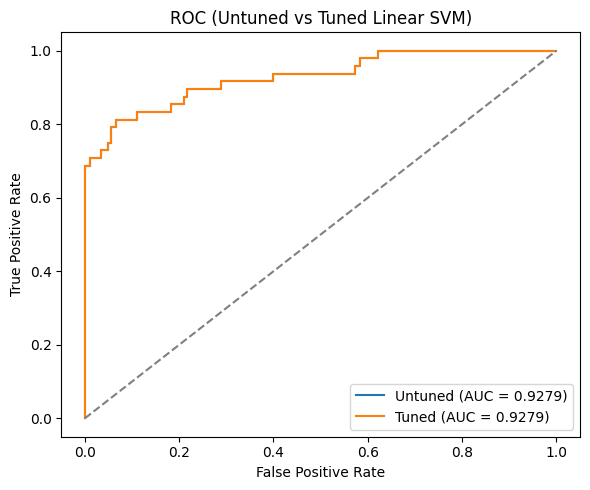

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

plt.figure(figsize=(6, 5))
for label, model in [("Untuned", models["Linear SVM"]),
                     ("Tuned",   grid.best_estimator_)]:
    ai_idx = list(model.classes_).index('ai')
    y_prob = model.predict_proba(X_test)[:, ai_idx]
    
    # Binarize labels: 'ai' =1, 'classical' = 0
    y_test_bin = label_binarize(y_test, classes=['classical', 'ai']).ravel()
    
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
    auc = roc_auc_score(y_test_bin, y_prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC (Untuned vs Tuned Linear SVM)")
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/enhancement_roc.png', dpi=120)
plt.show()

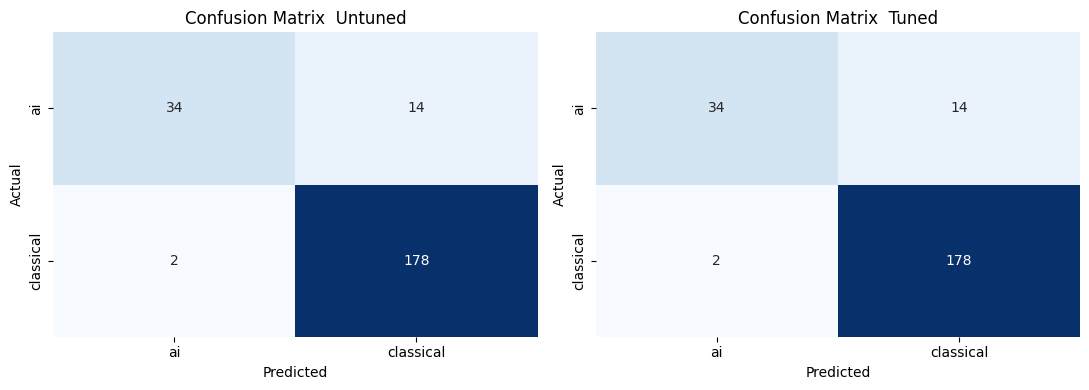

In [19]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, model) in zip(axes, [("Untuned", models["Linear SVM"]),
                                     ("Tuned",   grid.best_estimator_)]):
    cm = confusion_matrix(y_test, model.predict(X_test), labels=['ai', 'classical'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['ai', 'classical'],
                yticklabels=['ai', 'classical'], ax=ax, cbar=False)
    ax.set_title(f"Confusion Matrix  {name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig('../outputs/enhancement_confusion.png', dpi=120)
plt.show()

#### COMMENT ON THE GRAPHS

**Confusion Matrix:**
Both untuned and tuned Linear SVM produce identical predictions with 34 AI papers correctly 
identified, 14 missed, and 178 classical papers correctly identified with only 2 misclassified. 
The model misses some AI papers because the dataset is imbalanced that is, there are more 
classical papers (900) than AI papers (238).

**ROC Curve:**
Both curves overlap perfectly with AUC = 0.9279, confirming identical performance. 
This high AUC means the model has a 92.8% chance of correctly ranking a random AI paper 
above a random classical paper.

**Conclusion:**
Tuning confirmed the original parameters were already optimal. No improvement was gained and 
no performance was lost either.

In [21]:
import joblib

# Save the tuned model 
best_model = grid.best_estimator_

joblib.dump(best_model, '../deployment/best_model.joblib')
joblib.dump(tfidf,      '../deployment/vectorizer.joblib')

print("Saved:")
print("  deployment/best_model.joblib")
print("  deployment/vectorizer.joblib")

Saved:
  deployment/best_model.joblib
  deployment/vectorizer.joblib
